In [27]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [9]:
df = pd.read_csv('../data/cleaned_data_train.csv')

df = df[df["Exposure"] <= 1]

X = df.drop("ClaimNb", axis=1)
y = df['ClaimNb']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
clf = DecisionTreeRegressor(random_state=42, min_samples_leaf=5, max_depth=8)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
y_pred_train = clf.predict(x_train)


print('training error (MSE):', mean_squared_error(y_train, y_pred_train))
print('test error (MSE):', mean_squared_error(y_test, y_pred))

training error (MSE): 0.05501294394000206
test error (MSE): 0.05427685309935277


In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

MSE_train = []
MSE_test = []

for depth in range(1, 21):
    clf = DecisionTreeRegressor(random_state=42, min_samples_leaf=5, max_depth=depth)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    y_pred_train = clf.predict(x_train)

    MSE_train.append(mean_squared_error(y_train, y_pred_train))
    MSE_test.append(mean_squared_error(y_test, y_pred))





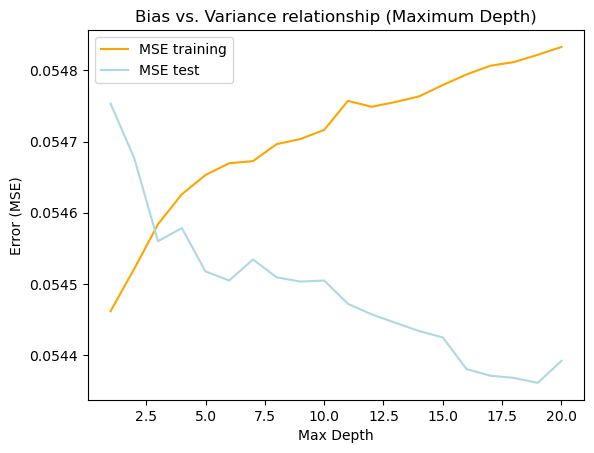

In [24]:
x = range(1,21)

plt.plot(x, MSE_train, linestyle = "-", label = "MSE training", c = "orange")
plt.plot(x, MSE_test, linestyle= "-", label = "MSE test", c = "lightblue")
plt.title("Bias vs. Variance relationship (Maximum Depth)")
plt.xlabel("Max Depth")
plt.ylabel("Error (MSE)")
plt.legend()
plt.show()

In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

MSE_train = []
MSE_test = []

for min_leafs in range(1, 21):
    clf = DecisionTreeRegressor(random_state=42, min_samples_leaf=min_leafs, max_depth=9)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    y_pred_train = clf.predict(x_train)

    MSE_train.append(mean_squared_error(y_train, y_pred_train))
    MSE_test.append(mean_squared_error(y_test, y_pred))

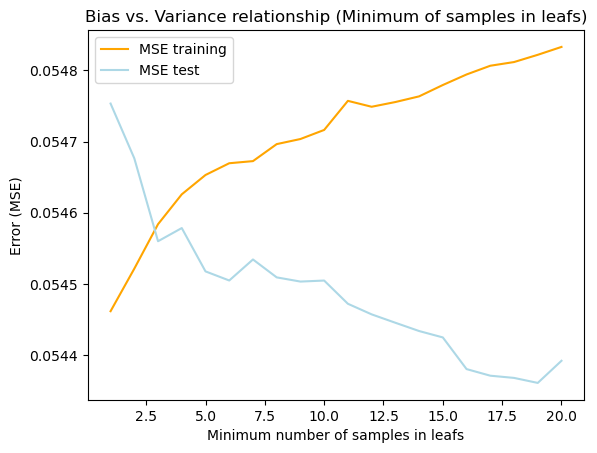

In [25]:
x = range(1,21)

plt.plot(x, MSE_train, linestyle = "-", label = "MSE training", c = "orange")
plt.plot(x, MSE_test, linestyle= "-", label = "MSE test", c = "lightblue")
plt.title("Bias vs. Variance relationship (Minimum of samples in leafs)")
plt.xlabel("Minimum number of samples in leafs")
plt.ylabel("Error (MSE)")
plt.legend()
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)


rf = RandomForestRegressor(random_state=42)

# Hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 5-fold cross validation
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',   # or f1, roc_auc, recall, etc
    n_jobs=-1             # use all CPU cores
)

# Fit on training data
grid.fit(x_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Use the best model to predict
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

KeyboardInterrupt: 